In [55]:
import keras
from keras.layers import LSTM, Dropout, Dense
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
data = pd.read_csv("btcusdt_1h.csv")
data['datetime'] = pd.to_datetime(data['datetime'])
data['signal'] = np.where(data['close'].shift(1) > data['close'], 1, -1)
data.dropna()
data


,datetime,open,high,low,close,volume,signal
0,2018-01-01 05:30:00,13715.65,13715.65,13400.01,13529.01,443.356199,-1
1,2018-01-01 06:30:00,13528.99,13595.89,13155.38,13203.06,383.697006,1
2,2018-01-01 07:30:00,13203.00,13418.43,13200.00,13330.18,429.064572,-1
3,2018-01-01 08:30:00,13330.26,13611.27,13290.00,13410.03,420.087030,-1
4,2018-01-01 09:30:00,13434.98,13623.29,13322.15,13601.01,340.807329,-1
...,...,...,...,...,...,...,...
35203,2022-01-12 01:30:00,42972.04,43095.26,42692.19,42800.38,1219.601780,1
35204,2022-01-12 02:30:00,42797.62,42823.69,42643.74,42659.20,702.103800,1
35205,2022-01-12 03:30:00,42664.71,42776.14,42597.41,42713.13,561.859930,-1
35206,2022-01-12 04:30:00,42713.12,42886.28,42633.97,42729.29,681.142010,-1


In [57]:
features = data.loc[: , ["close" , "volume"]].values
target = data['signal'].values


In [96]:
model = keras.Sequential()
model.add(LSTM(100 ,input_shape = (2,1)))
model.add(Dropout(0.5))
model.add(Dense(1,activation = "tanh"))
model.compile(loss = "mse" , optimizer = "adam")

In [97]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_4 (LSTM)               (None, 100)               40800     
                                                                 
 dropout_4 (Dropout)         (None, 100)               0         
                                                                 
 dense_4 (Dense)             (None, 1)                 101       
                                                                 
Total params: 40901 (159.77 KB)
Trainable params: 40901 (159.77 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [98]:
size = int(len(features)*0.8)
x_train , y_train = features[:size] , target[:size]
x_test , y_test = features[size:] , target[size:]

In [99]:
x_train

array([[13529.01    ,   443.356199],
       [13203.06    ,   383.697006],
       [13330.18    ,   429.064572],
       ...,
       [54466.36    ,  2069.621473],
       [54430.79    ,  1756.511006],
       [54350.54    ,  1667.112485]])

In [100]:
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
X_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [101]:
x_train

array([[[13529.01    ],
        [  443.356199]],

       [[13203.06    ],
        [  383.697006]],

       [[13330.18    ],
        [  429.064572]],

       ...,

       [[54466.36    ],
        [ 2069.621473]],

       [[54430.79    ],
        [ 1756.511006]],

       [[54350.54    ],
        [ 1667.112485]]])

In [109]:
model.fit(x_train , y_train , batch_size = 100 , epochs = 50)

Epoch 1/50
282/282 [==============================] - 2s 7ms/step - loss: 0.9999
Epoch 2/50
282/282 [==============================] - 2s 8ms/step - loss: 1.0001
Epoch 3/50
282/282 [==============================] - 1s 5ms/step - loss: 0.9999
Epoch 4/50
282/282 [==============================] - 1s 5ms/step - loss: 1.0004
Epoch 5/50
282/282 [==============================] - 1s 5ms/step - loss: 1.0000
Epoch 6/50
282/282 [==============================] - 1s 5ms/step - loss: 1.0007
Epoch 7/50
282/282 [==============================] - 1s 5ms/step - loss: 1.0003
Epoch 8/50
282/282 [==============================] - 2s 7ms/step - loss: 1.0006
Epoch 9/50
282/282 [==============================] - 2s 5ms/step - loss: 1.0003
Epoch 10/50
282/282 [==============================] - 2s 5ms/step - loss: 1.0001
Epoch 11/50
282/282 [==============================] - 2s 6ms/step - loss: 1.0002
Epoch 12/50
282/282 [==============================] - 2s 7ms/step - loss: 1.0006
Epoch 13/50
282/282 [====

In [110]:
model.evaluate(x_test , y_test)

221/221 [==============================] - 1s 5ms/step - loss: 1.0011


1.0011287927627563

221/221 [==============================] - 1s 3ms/step


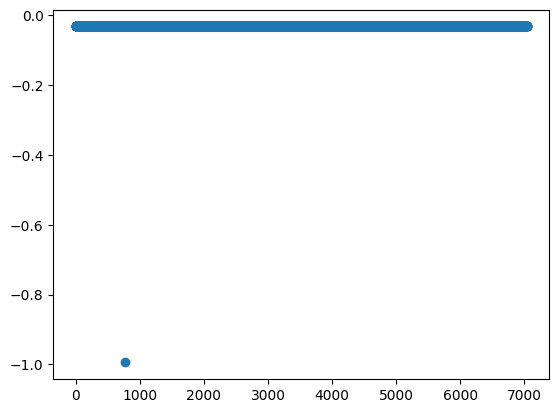

In [111]:
model.predict(x_test).shape
plt.scatter(x = range(len(model.predict(x_test)) ), y= model.predict(x_test))
plt.show()

In [105]:
pred = np.sign(model.predict(X_test, verbose=1))

TypeError: in user code:

    File "c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py", line 2440, in predict_function  *
        return step_function(self, iterator)
    File "c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py", line 2425, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py", line 2413, in run_step  **
        outputs = model.predict_step(data)
    File "c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py", line 2381, in predict_step
        return self(x, training=False)
    File "c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "c:\U